# Importing Library Dependencies

In [47]:
#For dataset upload
from google.colab import files
from google.colab import drive

#For data preprocessing and Error analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

#For CatBoost
import catboost
from catboost import CatBoostClassifier
from catboost import Pool, cv

#For splitting data sets, calculating performance metrics
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, precision_recall_curve, recall_score, f1_score, classification_report, confusion_matrix

#For distance calculation
from geopy.distance import geodesic

#To ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Uploading the raw credit card transactions dataset
Source: [Kaggle Credit Card Transactions Dataset](https://www.kaggle.com/datasets/priyamchoksi/credit-card-transactions-dataset)

In [49]:
#Upload dataset
#dataset = files.upload()
#drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/ML Project/credit_card_transactions.csv'
df = pd.read_csv(file_path)

print('Shape=', df.shape)
df.head()
df.info()
df['is_fraud'].value_counts(normalize=True)

Shape= (1296675, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 1

,proportion
is_fraud,
0,0.994211
1,0.005789


# Data Preprocessing

Before beginning feature engineering, I performed basic data preprocessing to remove PII and drop features that would likely not be available in a real-world fraud detection dataset. This included handling null values, removing redundant or noisy features, and applying PII best practices such as hashing credit card numbers.

In [50]:
#Dropping PII features that would likely not be present in a real-world dataset, along with redundant features to reduce dimensionality and potential for overfitting
df.drop(columns=['Unnamed: 0','first', 'last', 'trans_num','unix_time'], inplace=True)

In [51]:
#Tokenize the CC numbers for PII best practice
df['cc_num'] = df['cc_num'].apply(lambda x: hash(x))

In [52]:
#Stip the tags from the merchant names
df['merchant'] = df['merchant'].str.replace('^fraud_', '', regex=True)

In [53]:
#Count Nulls in the dataset per feature:
null_count = df.isnull().sum()
print(null_count)

trans_date_trans_time         0
cc_num                        0
merchant                      0
category                      0
amt                           0
gender                        0
street                        0
city                          0
state                         0
zip                           0
lat                           0
long                          0
city_pop                      0
job                           0
dob                           0
merch_lat                     0
merch_long                    0
is_fraud                      0
merch_zipcode            195973
dtype: int64


In [54]:
#Drop merchant zipcode from the dataset due to 15%+ nulls and overlap with merch_lat and merch_long
df.drop(columns=['merch_zipcode'], inplace=True)

In [55]:
#View the updated dataset:
null_count = df.isnull().sum()
print(null_count)

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


# Feature Engineering

To improve the model's ability to detect fraud cases, I engineered multiple features that successfully identified correlations with the fruad class. This involved bucketing high-cardinality features and creating flags which identified trends in user behavior, location patterns, and time of day. These included deriving the users age from their DOB, detecting sudden impossible location jumps, and measuring the distance between the user and merchant. I also bucketed transaction amounts into percentiles, created night-time flags, added transaction frequency metrics, and extracted time-based components like hour and weekday. While not all of these features ended up being of high importance and some were dropped from the dataset, multiple of these features did successfully capture fraud-related signals that ended up providing high feature values.

In [56]:
#Concatenate State and City into a single feature and remove the original features to reduce dimensionality
df['location'] = df['city'] + ', ' + df['state']
df.drop(columns=['city', 'state'], inplace=True)

In [57]:
#Computing Age from DOB and replacing the dob feature with age in the dataset:
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
df.drop(columns=['dob'], inplace=True)

In [58]:
#Flag to identify credit card number transactions which have occurred in an unrealistic distance/time.

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

#Sort by cc_num and time
df = df.sort_values(by=['cc_num', 'trans_date_trans_time'])

#Compute prior lat/long/time
df['prev_lat'] = df.groupby('cc_num')['lat'].shift(1)
df['prev_long'] = df.groupby('cc_num')['long'].shift(1)
df['prev_time'] = df.groupby('cc_num')['trans_date_trans_time'].shift(1)

#Calculate distance in miles
df['geo_distance'] = 0
valid_coords = df['prev_lat'].notnull() & df['prev_long'].notnull()
df.loc[valid_coords, 'geo_distance'] = df.loc[valid_coords].apply(
    lambda row: geodesic((row['lat'], row['long']), (row['prev_lat'], row['prev_long'])).miles, axis=1
)

#Calculate Time delta in hours
df['time_delta_hours'] = (df['trans_date_trans_time'] - df['prev_time']).dt.total_seconds() / 3600

#Flag: True when user traveled over 1000 miles in under 2 hours
df['location_jump_flag'] = ((df['geo_distance'] > 300) & (df['time_delta_hours'] < 2)).astype(int)

In [59]:
#Deriving the distance between the merchant and consumer
def compute_distance(row):
    user_loc = (row['lat'], row['long'])
    merch_loc = (row['merch_lat'], row['merch_long'])
    return geodesic(user_loc, merch_loc).miles

df['distance_miles'] = df.apply(compute_distance, axis=1)

In [60]:
#Concatenate rounding lat/long to reduce overfitting and concatenating into a single feature
df['user_location'] = df['lat'].round(2).astype(str) + "_" + df['long'].round(2).astype(str)
df['merchant_location'] = df['merch_lat'].round(2).astype(str) + "_" + df['merch_long'].round(2).astype(str)

#Drop the prior features
df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)

In [61]:
#Bucket the AMT column into percentile ranges.
df['amt_bucket'] = pd.qcut(df['amt'], q=5, labels=['B1', 'B2', 'B3', 'B4', 'B5'])

#Normalize amt by taking the log
df['log_amt'] = np.log(df['amt'] + 1)

In [62]:
#Count the TXN amount of each user, adding it as a feature:
df['user_txn_count'] = df.groupby('cc_num')['cc_num'].transform('count')

In [63]:
#Transform trans_date_trans_time into datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

#Calculating the time between transactions and adding it to the dataset as a feature
df = df.sort_values(['cc_num', 'trans_date_trans_time'])
df['time_since_last_txn'] = (
    df.groupby('cc_num')['trans_date_trans_time']
    .diff()
    .dt.total_seconds()
    .fillna(0)
)

In [64]:
#Calculating time-based features from the transaction timestamp
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['weekday'] = df['trans_date_trans_time'].dt.weekday
df['month'] = df['trans_date_trans_time'].dt.month
df['is_night'] = df['hour'].apply(lambda x: 1 if (x < 6 or x >= 22) else 0)

In [65]:
#Data Set overview post feature engineering:
print("Shape:", df.shape)
print("\nColumn Info:")
print(df.dtypes)

print("\nSample of the dataset:")
display(df.head())

print("\nSummary statistics:")
display(df.describe(include='all').transpose())

Shape: (1296675, 31)

Column Info:
trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
gender                           object
street                           object
zip                               int64
city_pop                          int64
job                              object
is_fraud                          int64
location                         object
age                               int32
prev_lat                        float64
prev_long                       float64
prev_time                datetime64[ns]
geo_distance                      int64
time_delta_hours                float64
location_jump_flag                int64
distance_miles                  float64
user_location                    object
merchant_location                object
amt_bucket                     category
log_amt                         float64
user_

,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,zip,city_pop,job,...,merchant_location,amt_bucket,log_amt,user_txn_count,time_since_last_txn,hour,day,weekday,month,is_night
1017,2019-01-01 12:47:15,60416207185,"Jones, Sawayn and Romaguera",misc_net,7.27,F,9886 Anita Drive,82514,1645,Information systems manager,...,43.97_-109.74,B1,2.112635,1518,0.0,12,1,1,1,0
2724,2019-01-02 08:44:57,60416207185,Berge LLC,gas_transport,52.94,F,9886 Anita Drive,82514,1645,Information systems manager,...,42.02_-109.04,B3,3.987872,1518,71862.0,8,2,2,1,0
2726,2019-01-02 08:47:36,60416207185,Luettgen PLC,gas_transport,82.08,F,9886 Anita Drive,82514,1645,Information systems manager,...,42.96_-109.16,B4,4.419804,1518,159.0,8,2,2,1,0
2882,2019-01-02 12:38:14,60416207185,Daugherty LLC,kids_pets,34.79,F,9886 Anita Drive,82514,1645,Information systems manager,...,42.23_-108.75,B3,3.577669,1518,13838.0,12,2,2,1,0
2907,2019-01-02 13:10:46,60416207185,Beier and Sons,home,27.18,F,9886 Anita Drive,82514,1645,Information systems manager,...,43.32_-108.09,B2,3.338613,1518,1952.0,13,2,2,1,0



Summary statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
trans_date_trans_time,1296675,NaN,NaN,NaN,2019-10-03 12:47:28.070214144,2019-01-01 00:00:18,2019-06-03 19:12:22.500000,2019-10-03 07:35:47,2020-01-28 15:02:55.500000,2020-06-21 12:13:37,NaN
cc_num,1296675.0,NaN,NaN,NaN,123095807947975664.0,60416207185.0,180042946491150.0,3521417320836166.0,4642255475285942.0,2293892398663551232.0,469203866656969216.0
merchant,1296675,693,Kilback LLC,4403,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1296675,14,gas_transport,131659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amt,1296675.0,NaN,NaN,NaN,70.351035,1.0,9.65,47.52,83.14,28948.9,160.316039
gender,1296675,2,F,709863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
street,1296675,983,864 Reynolds Plains,3123,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip,1296675.0,NaN,NaN,NaN,48800.671097,1257.0,26237.0,48174.0,72042.0,99783.0,26893.222476
city_pop,1296675.0,NaN,NaN,NaN,88824.440563,23.0,743.0,2456.0,20328.0,2906700.0,301956.360689
job,1296675,494,Film/video editor,9779,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Split the data sets into Train, Dev, and Test sets

**Data Splitting Methodology:**
The full dataset of approximately 1.2 million credit card transactions was split into three parts: 70% for train, 15% for dev, and 15% for test.The binary target variable is_fraud was used to perform stratified sampling, ensuring that the 2 classes were evenly distributed across the 3 datasets. No oversampling or undersampling techniques were applied. as CatBoost’s auto_class_weights = 'Balanced' parameter was used to effectively handle the class imbalance.

In [66]:
#Split the 1.2~ million row dataset into 3 parts: 70% for train, 15% for dev, and 15% for test. Utilizing stratified sampling to ensure that the 2 classes are evenly distributed.
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
X_dev, X_test, y_dev, y_test = train_test_split(X_temp, y_temp, stratify=y_temp, test_size=0.5, random_state=42)

# Data visualization on the transformed dataset

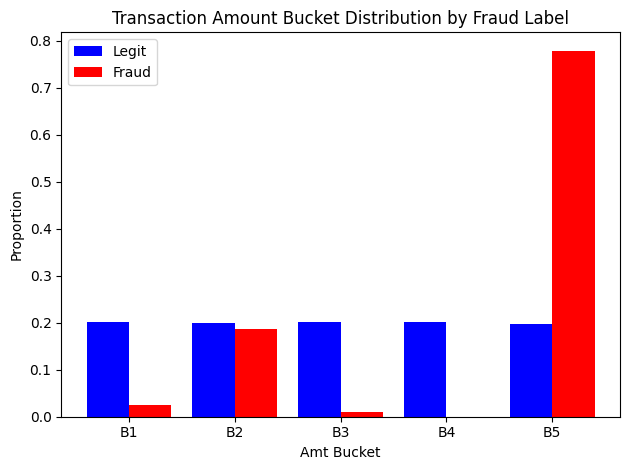

In [67]:
# Basic Data Visualization - Fraud and Legitimate transaction distribution by Amt Bucket:
train_df = X_train.copy()
train_df['is_fraud'] = y_train

plt.figure()
fraud_counts = train_df[train_df['is_fraud'] == 1]['amt_bucket'].value_counts(normalize=True).sort_index()
legit_counts = train_df[train_df['is_fraud'] == 0]['amt_bucket'].value_counts(normalize=True).sort_index()

bar_width = 0.4
x = range(len(fraud_counts))

plt.bar([i - bar_width/2 for i in x], legit_counts, width=bar_width, label='Legit', color='blue')
plt.bar([i + bar_width/2 for i in x], fraud_counts, width=bar_width, label='Fraud', color='red')

plt.xticks(ticks=x, labels=fraud_counts.index)
plt.xlabel("Amt Bucket")
plt.ylabel("Proportion")
plt.title("Transaction Amount Bucket Distribution by Fraud Label")
plt.legend()
plt.tight_layout()

<Axes: title={'center': 'Fraud Rate by Category'}, ylabel='category'>

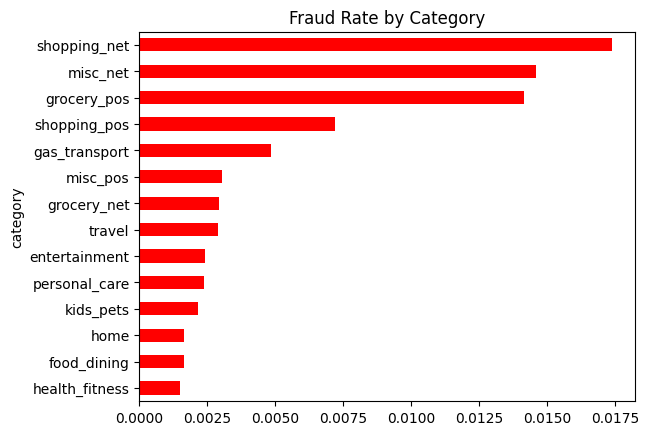

In [68]:
#Basic Data Visualization - Visualize data by Category flag:
fraud_by_category = train_df.groupby('category')['is_fraud'].mean().sort_values()
fraud_by_category.plot(kind='barh', color='red', title='Fraud Rate by Category')

Text(0.5, 1.0, 'Age Distribution by Fraud Label')

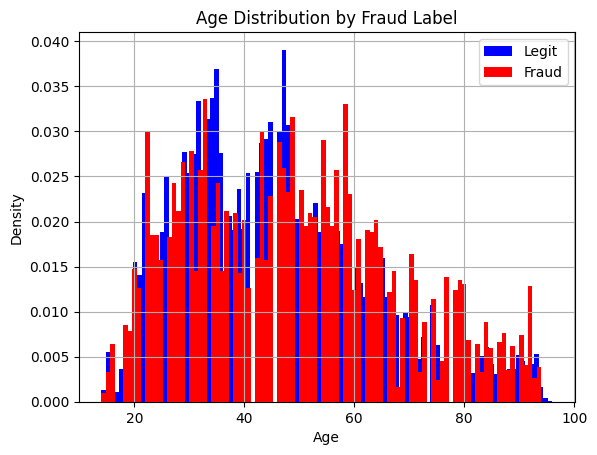

In [69]:
#Basic Data Visualization - Fraud and Legitimate transaction distribution by Age:
train_df = X_train.copy()
train_df['is_fraud'] = y_train

plt.figure()
train_df[train_df['is_fraud'] == 0]['age'].hist(bins=100, color='blue', label='Legit', density=True)
train_df[train_df['is_fraud'] == 1]['age'].hist(bins=100, color='red', label='Fraud', density=True)
plt.legend()
plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Age Distribution by Fraud Label")

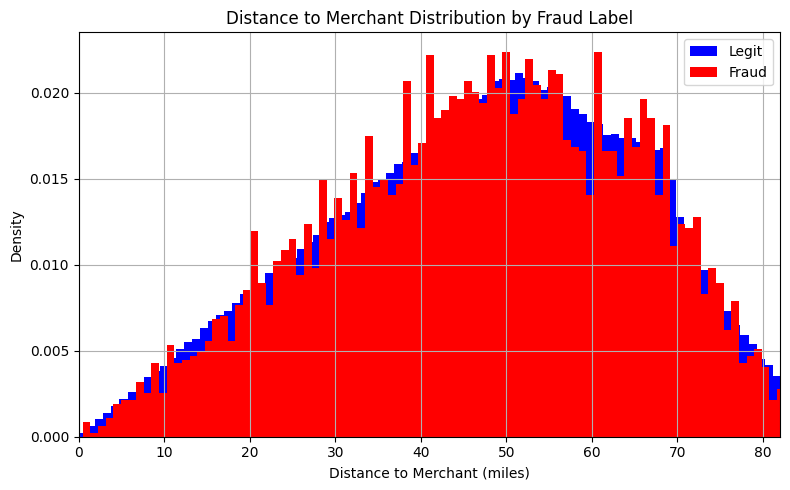

In [70]:
#Basic Data Visualization - Fraud and Legitimate transaction distribution by Distance to Merchant:
train_df = X_train.copy()
train_df['is_fraud'] = y_train

plt.figure(figsize=(8, 5))
train_df[train_df['is_fraud'] == 0]['distance_miles'].hist(bins=100, color='blue', label='Legit', density=True)
train_df[train_df['is_fraud'] == 1]['distance_miles'].hist(bins=100, color='red', label='Fraud', density=True)
plt.legend()
plt.xlabel("Distance to Merchant (miles)")
plt.ylabel("Density")
plt.title("Distance to Merchant Distribution by Fraud Label")
plt.xlim(0, train_df['distance_miles'].quantile(0.99))  # Optional: cut off extreme outliers
plt.tight_layout()

Transaction Counts:
 is_night        Is Day  Is Night
is_fraud                        
No. Legitimate  634598    267820
No. Fraud          711      4543 



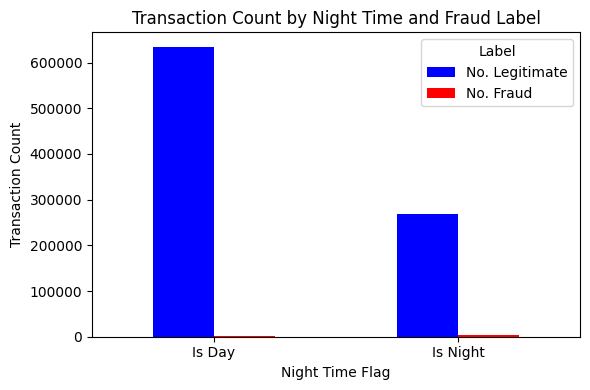

In [71]:
#Basic Data Visualization - Fraud by night flag:
train_df = X_train.copy()
train_df['is_fraud'] = y_train
night_counts = train_df.groupby(['is_fraud', 'is_night']).size().unstack().rename(index={0: 'No. Legitimate', 1: 'No. Fraud'}, columns={0: 'Is Day', 1: 'Is Night'})
print("Transaction Counts:\n", night_counts, "\n")
night_counts.T.plot(kind='bar', figsize=(6, 4), color=['blue', 'red'], title='Transaction Count by Night Time and Fraud Label')
plt.xlabel('Night Time Flag')
plt.ylabel('Transaction Count')
plt.legend(title='Label')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Fraud Rate by Hour of Day'}, xlabel='hour'>

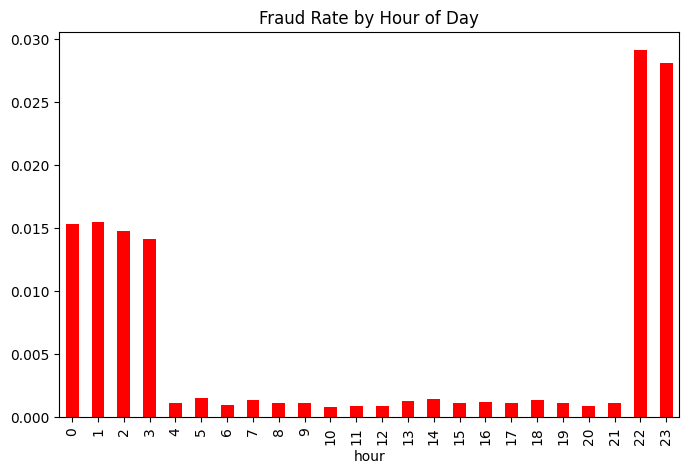

In [72]:
#Basic Data Visualization - Fraud by hour:
fraud_rate_by_hour = train_df.groupby('hour')['is_fraud'].mean()
fraud_rate_by_hour.plot(kind='bar', color='red', title='Fraud Rate by Hour of Day', figsize=(8, 5))

is_fraud                  0     1
location_jump_flag               
0                   1289169  7506



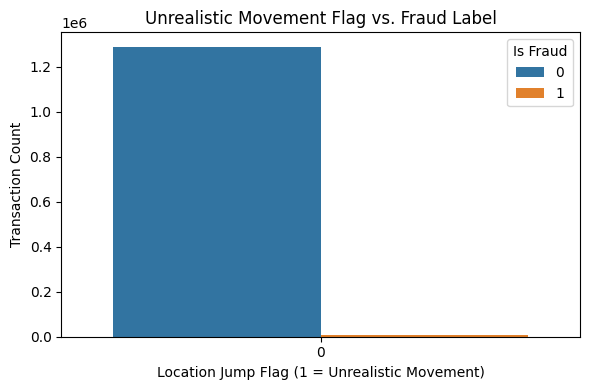

In [73]:
#Basic Data Visualization - Fraud by Location jump flag

print(df.groupby(['location_jump_flag', 'is_fraud']).size().unstack(fill_value=0))
print()

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='location_jump_flag', hue='is_fraud')
plt.title("Unrealistic Movement Flag vs. Fraud Label")
plt.xlabel("Location Jump Flag (1 = Unrealistic Movement)")
plt.ylabel("Transaction Count")
plt.legend(title="Is Fraud")
plt.tight_layout()
plt.show()

In [74]:
#Drop columns with low feature importance identified after prior iterations:
cols_to_drop = [
    'merchant_location',
    'location','street', 'distance_miles','job','location_jump_flag', 'is_fraud','prev_time','prev_lat','geo_distance'
]
# cols_to_drop = [
#     'location', 'street','cc_num','distance_miles'
# ]

X_train.drop(columns=cols_to_drop, inplace=True, errors='ignore')
X_dev.drop(columns=cols_to_drop, inplace=True, errors='ignore')
X_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Establish Baselines

I began with two baselines created through rule-based predictions that I based on fraud correlations I had noticed during the data visualization phase. <br>**The first baseline** predicted that every transaction was legitimate, which yielded a 99.4% accuracy rate but a 0% F1 score. <br>**The second baseline** predicted fraud only for transactions in the highest amount percentile, occurring at night, and flagged with an impossible movement indicator. This yielded an F1 score of .21~.


In [75]:
#Baseline 1: Every transaction is legitimate.
y_train_baseline1 = [0] * len(y_train)

print("Baseline 1 - Predict All Legitimate (0):\n")
print("Accuracy: ", accuracy_score(y_train, y_train_baseline1))
print("Precision: ", precision_score(y_train, y_train_baseline1, zero_division=0))
print("Recall: ", recall_score(y_train, y_train_baseline1))
print("F1 Score: ", f1_score(y_train, y_train_baseline1))

Baseline 1 - Predict All Legitimate (0):

Accuracy:  0.994211565411294
Precision:  0.0
Recall:  0.0
F1 Score:  0.0


In [76]:
#Baseline 2: All transactions are legitimate except the highest percentile of transaction amounts occurring at night time within the 2 highest fraud categories:
baseline_prediction2 = (X_test['amt_bucket'] == 'B5') & (X_test['is_night'] == 1) & (X_test['category'].isin(['shopping_net', 'misc_net']))


#Evaluate Performance
print("Baseline 2:")
print("Precision:", precision_score(y_test, baseline_prediction2))
print("Recall:", recall_score(y_test, baseline_prediction2))
print("F1 Score:", f1_score(y_test, baseline_prediction2))

Baseline 2:
Precision: 0.15821312238250348
Recall: 0.3019538188277087
F1 Score: 0.20763358778625954


# Train Catboost Model

**Why Catboost was Chosen**<br>
While solving this problem, I experimented with multiple models including LSTMs for temporal pattern detection and Isolation Forest for anomaly detection. However, the gradient boosted tree model CatBoost ultimately provided the best performance with lower complexity and better overall performance when compared to transformer-based models. Catboost provided multiple benefits including natively handling categorical variables, which performed well with some of the categorical features created during the feature engineering phase.

In [77]:
#Identify categorical features:
print(df.dtypes)

trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
gender                           object
street                           object
zip                               int64
city_pop                          int64
job                              object
is_fraud                          int64
location                         object
age                               int32
prev_lat                        float64
prev_long                       float64
prev_time                datetime64[ns]
geo_distance                      int64
time_delta_hours                float64
location_jump_flag                int64
distance_miles                  float64
user_location                    object
merchant_location                object
amt_bucket                     category
log_amt                         float64
user_txn_count                    int64


In [78]:
#Train the catboost model using high value categorical features
categorical_features = ['category', 'gender', 'amt_bucket','merchant','user_location']

cb_model2 = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.03,
    eval_metric='F1',
    verbose=50,
    random_seed=123,
    auto_class_weights='Balanced',
    early_stopping_rounds=100
)

cb_model2.fit(
    X_train, y_train,
    cat_features=categorical_features,
    eval_set=(X_dev, y_dev),
    use_best_model=True
)

0:	learn: 0.9189309	test: 0.9199961	best: 0.9199961 (0)	total: 1.27s	remaining: 4m 13s
50:	learn: 0.9588338	test: 0.9583321	best: 0.9583321 (50)	total: 1m 19s	remaining: 3m 52s
100:	learn: 0.9681001	test: 0.9694142	best: 0.9694142 (100)	total: 2m 36s	remaining: 2m 32s
150:	learn: 0.9744732	test: 0.9762567	best: 0.9762567 (150)	total: 3m 53s	remaining: 1m 15s
199:	learn: 0.9788454	test: 0.9790095	best: 0.9790221 (196)	total: 5m 7s	remaining: 0us

bestTest = 0.9790221481
bestIteration = 196

Shrink model to first 197 iterations.


In [87]:
#Predict on Test Data
y_probs = cb_model2.predict_proba(X_test)[:, 1]

#Using the optimized threshold
y_pred = (y_probs >= 0.9444).astype(int)

Confusion Matrix:


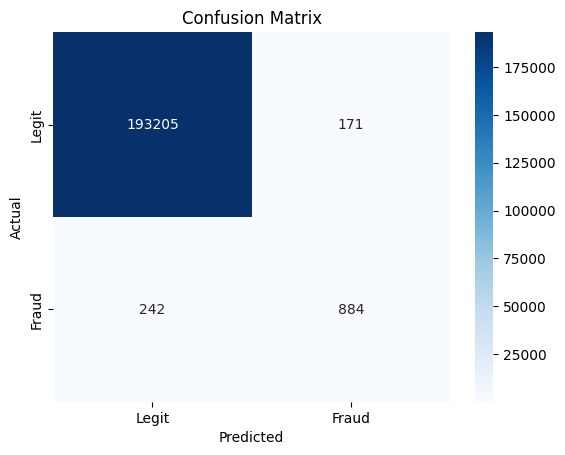


Classification Report:
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    193376
       Fraud       0.84      0.79      0.81      1126

    accuracy                           1.00    194502
   macro avg       0.92      0.89      0.90    194502
weighted avg       1.00      1.00      1.00    194502

F1 Score: 0.8106373223292068
Precision: 0.837914691943128
Recall: 0.7850799289520426


In [88]:
#Evaluate Model Performance:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

In [84]:
#Get feature importance:
cb_model2.get_feature_importance(prettified=True)

,Feature Id,Importances
0,amt,24.921628
1,category,21.618086
2,log_amt,15.940030
3,hour,7.084855
4,is_night,6.221624
5,amt_bucket,5.061747
6,age,3.523255
7,time_delta_hours,3.330556
8,time_since_last_txn,2.296412
9,user_txn_count,2.183652


# Hyperparameter Optimizations

**Hyperparameter Optimization:** Once I reached a satisfactory F1 score through feature engineering and model selection, I performed hyperparameter tuning using RandomizedSearchCV from the sklearn library. I used 3-fold cross-validation across a range of hyperparameter combinations to efficiently identify the best-performing configuration.

In [ ]:
#Define categorical features
categorical_features = ['category', 'gender', 'amt_bucket','merchant','user_location']

# Define hyperparameters for testing
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
    'iterations': [200, 300, 500],
    'l2_leaf_reg': [1, 3, 7]
}

#Initialize CatBoost model with initial parameters
cb_model = CatBoostClassifier(
    eval_metric='F1',
    verbose=0,
    random_seed=123,
    auto_class_weights='Balanced',
    early_stopping_rounds=50
)

#Perform randomized search with cross-validation using F1 score as the metric
grid_search = RandomizedSearchCV(
    estimator=cb_model,
    param_distributions=param_grid,
    n_iter=5,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

#Train the model with random search using the training data, passing categorical features
grid_search.fit(
    X_train, y_train,
    **{'cat_features': categorical_features}
)

**Threshold Optimization:**
<br>To optimize classification performance, I calculated predicted probabilities from the final CatBoost model and used the precision_recall_curve function to evaluate precision and recall on different thresholds. The default 0.5 threshold was yielding poor results so I opted to compute the F1 score at each point and then selected the threshold that maximized overall performance.

In [92]:
# #Print the best combination of hyperparameters and the corresponding f1 score
print("Best Parameters Found:", grid_search.best_params_)
print("Best Cross-Validated F1 Score:", (grid_search.best_score_))

In [86]:
#Find the threshold with the highest f1 score:

y_scores = cb_model2.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# find threshold that maximizes F1
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print("Best threshold for F1:", best_threshold)


Best threshold for F1: 0.9443720488079539


# Error Analysis

To understand the model’s weaknesses, I analyzed 10 of the misclassified transactions resulting from the predictions on the test set, focusing on:
<br> False negatives / fraud cases missed by the model
<br>- False positives / legitimate transactions flagged as fraud
<br>The top 10 most confidently incorrect predictions showed the following patterns:

*   Most false positives had very high fraud probabilities, as high as 0.99 in some cases, indicating there are strong outliers within the feature set.
*   Many misclassified samples shared traits like high amounts, night hours, and high transaction frequency, which commonly overlap in both both legitimate and fraudulent behavior, making outliers hard to classify while generalizing to unseen data.

Based on these results, the model might benefit from:
<br>- Additional features that provide time-series signal
<br>- Better handling of outlier feature values


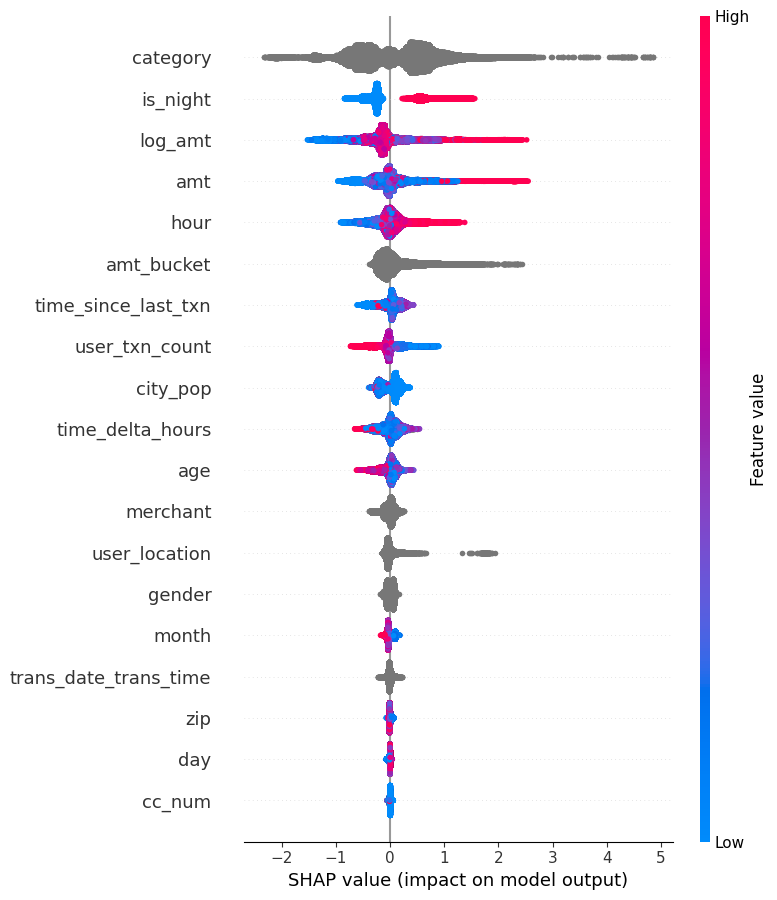

In [45]:
#Visualize feature importance to better understand Decision Making
explainer = shap.TreeExplainer(cb_model2)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=X_test.columns)

In [44]:
#Output the top 10 misclassified transactions with highest predicted fraud probability
y_pred = cb_model2.predict(X_test)
y_proba = cb_model2.predict_proba(X_test)[:, 1]

error_df = X_test.copy()
error_df['true_label'] = y_test.values
error_df['predicted'] = y_pred
error_df['prob_fraud'] = y_proba

misclassified = error_df[error_df['true_label'] != error_df['predicted']]
misclassified_sorted = misclassified.sort_values(by='prob_fraud', ascending=False)
misclassified_sorted.head(10)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,zip,city_pop,age,time_delta_hours,...,log_amt,user_txn_count,time_since_last_txn,hour,day,month,is_night,true_label,predicted,prob_fraud
567952,2019-08-29 22:42:48,30518196150127,"Bins, Balistreri and Beatty",shopping_pos,1329.14,F,60963,1807,44,0.974722,...,7.193039,496,3509.0,22,29,8,1,0,1,0.997454
7580,2019-01-05 22:57:12,2268221587779419,Schumm PLC,shopping_net,1067.73,F,98665,299480,34,NaN,...,6.974226,500,0.0,22,5,1,1,0,1,0.997279
846751,2019-12-14 23:42:22,4658117080136,"Kerluke, Considine and Macejkovic",misc_net,811.07,M,87313,5662,30,1.033611,...,6.699587,1004,3721.0,23,14,12,1,0,1,0.995922
1170678,2020-05-03 23:13:51,676298633337,Metz-Boehm,shopping_pos,658.94,F,26339,255,49,0.251944,...,6.492149,1528,907.0,23,3,5,1,0,1,0.995874
574729,2019-09-01 05:40:22,346243940647414,Kris-Weimann,misc_net,669.68,M,43076,9051,36,0.688333,...,6.508292,492,2478.0,5,1,9,1,0,1,0.994326
1266597,2020-06-09 23:15:07,340951438290556,Hickle Group,shopping_pos,981.99,F,10962,5950,49,0.921389,...,6.890599,1517,3317.0,23,9,6,1,0,1,0.992283
76636,2019-02-14 22:55:29,180018375329178,"Bahringer, Schoen and Corkery",shopping_pos,1198.95,F,49259,2523,31,0.452500,...,7.090035,1521,1629.0,22,14,2,1,0,1,0.991813
959720,2020-01-20 22:24:59,4518350514020532,Hickle Group,shopping_pos,968.92,M,33873,14742,27,12.847500,...,6.877214,1006,46251.0,22,20,1,1,0,1,0.991696
752663,2019-11-17 23:55:40,3598014571045296,Jewess LLC,shopping_pos,1084.78,F,27837,5903,26,1.299444,...,6.990054,1001,4678.0,23,17,11,1,0,1,0.991630
924820,2019-12-31 23:46:25,4169759661243568,"Swaniawski, Lowe and Robel",shopping_pos,2194.47,F,17041,213,47,0.014722,...,7.694151,2069,53.0,23,31,12,1,0,1,0.990768


# Overall Results

<br>Ultimately, the CatBoost model trained on the engineered credit card transaction dataset yielded the following results on the test dataset:

<br>F1 Score: 0.81
<br>Precision: 0.83
<br>Recall: 0.78
<br>Best Threshold: 0.9444

<br> The model outperformed both rule-based baselines and shows that Catboost can be a lightweight and effective solution for identifying fraudulent transactions within a transaction dataset containing significant class imbalance.
<br>Potential improvements to make this model more production-ready:
<br>Ensemble the model with other tree-based or deep learning models to reduce

*   Ensemble the model with other tree-based or deep-learning models to reduce the residual error and improve generalization.
*   Introduce a third class for low-confidence cases, flagging them for manual review by a human rather than automated rejection.
*   Engineer additional time-series based features to better capture user behavior and user transaction trends.